In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict
from scipy.stats import norm
from matplotlib.colors import ListedColormap

In [ ]:
# data_path = "data/11900_2025-11-04_NASA_FTJ_04_ID01-21_PWR.csv"
data_path = "8300_2025-11-13_NASA-FTJ-04_ID05-29_LTP-LTD.csv"
# data_path = "data/3000_2025-11-11_NASA-FTJ-04_ID17-08_LTP-LTD.csv"
# data_path = "data/1300_2025-11-14_NASA-FTJ-04_ID21-13_LTP-LTD.csv"
# data_path = "data/5300_2025-11-14_NASA-FTJ-04_ID14-13_LTP-LTD.csv"
# data_path = "data/finegrain/2025-11-10_NASA-FTJ-04_ID10-05_PWR.csv"




df = pd.read_csv(data_path, skiprows=21)

In [50]:
#Show name of the columns
print(df.columns)

Index(['cycle\tV_write\tR_neg_ohm\tR_pos_ohm\tI_neg_A\tI_pos_A\tJ_neg_A_per_m2\tJ_pos_A_per_m2\tVread_min_V\tVread_max_V'], dtype='object')


In [51]:
#Split the columns when \t is present
df = df['cycle\tV_write\tR_neg_ohm\tR_pos_ohm\tI_neg_A\tI_pos_A\tJ_neg_A_per_m2\tJ_pos_A_per_m2\tVread_min_V\tVread_max_V'].str.split('\t', expand=True)

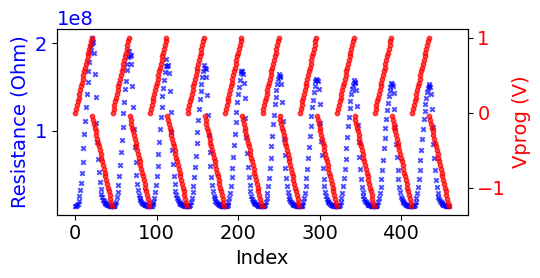

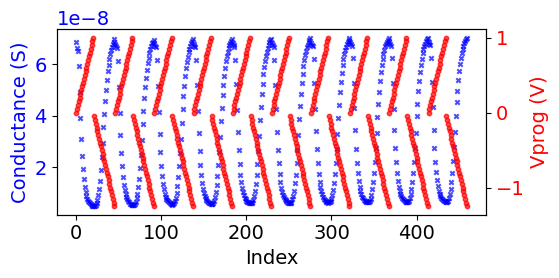

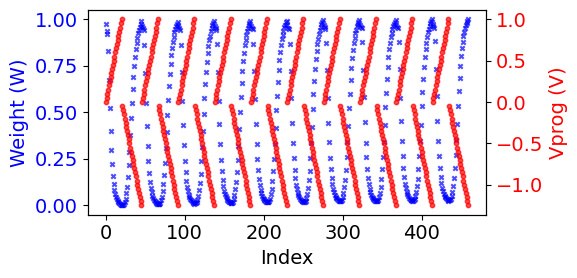

In [52]:
cycle = df[0]
V_write = df[1]
R = df[3]
R_array = np.array(R.astype(float))
V_write_array = np.array(V_write.astype(float))
G_array = 1.0 / R_array
G_min = np.min(G_array)
G_max = np.max(G_array)
W_array = (G_array - G_min) / (G_max - G_min)

indices = np.arange(len(R)) 
plt.figure(figsize=(6,3))
#Set font size to 14
plt.rcParams.update({'font.size': 14})

#Make another Y axis on the right side for V_write
ax = plt.gca()

# plot R on the left y-axis
ax.scatter(indices, R_array, c='blue', s=10, label='R (Ohm)', marker="x", alpha=0.7)
ax.set_ylabel('Resistance (Ohm)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# create a twin axis for V_write on the right y-axis
ax2 = ax.twinx()
ax2.scatter(indices, V_write_array, c='red', s=10, label='V_write (V)', marker='o', alpha=0.7)
ax2.set_ylabel('Vprog (V)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax.set_xlabel('Index')

#Save the figure as svg
plt.tight_layout()
name = os.path.basename(data_path).split('.')[0]
plt.savefig(f'{name}_R_and_Vwrite_vs_Index.svg')

plt.figure(figsize=(6,3))
#Set font size to 14
plt.rcParams.update({'font.size': 14})

#Make another Y axis on the right side for V_write
ax = plt.gca()

# plot W on the left y-axis
ax.scatter(indices, G_array, c='blue', s=10, label='W', marker="x", alpha=0.7)
ax.set_ylabel('Conductance (S)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# create a twin axis for V_write on the right y-axis
ax2 = ax.twinx()
ax2.scatter(indices, V_write_array, c='red', s=10, label='V_write (V)', marker='o', alpha=0.7)
ax2.set_ylabel('Vprog (V)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax.set_xlabel('Index')

#Save the figure as svg
plt.tight_layout()
plt.savefig(f'{name}_G_and_Vwrite_vs_Index.svg')



plt.figure(figsize=(6,3))
#Set font size to 14
plt.rcParams.update({'font.size': 14})

#Make another Y axis on the right side for V_write
ax = plt.gca()

# plot W on the left y-axis
ax.scatter(indices, W_array, c='blue', s=10, label='W', marker="x", alpha=0.7)
ax.set_ylabel('Weight (W)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# create a twin axis for V_write on the right y-axis
ax2 = ax.twinx()
ax2.scatter(indices, V_write_array, c='red', s=10, label='V_write (V)', marker='o', alpha=0.7)
ax2.set_ylabel('Vprog (V)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax.set_xlabel('Index')

#Save the figure as svg
plt.tight_layout()
plt.savefig(f'{name}_W_and_Vwrite_vs_Index.svg')



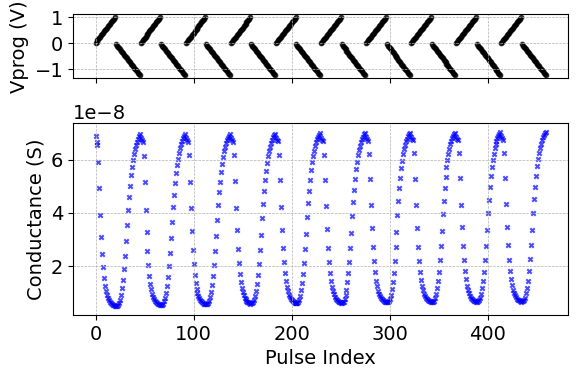

In [61]:
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Top subplot: V_write
ax_top.scatter(indices, V_write_array, c='black', s=10, label='Vprog (V)', marker='o', alpha=0.7)
ax_top.set_ylabel('Vprog (V)', color='black')
ax_top.tick_params(axis='y', labelcolor='black')

# Bottom subplot: Conductance
ax_bottom.scatter(indices, G_array, c='blue', s=10, label='G (S)', marker="x", alpha=0.7)
ax_bottom.set_ylabel('Conductance (S)', color='black')
ax_bottom.tick_params(axis='y', labelcolor='black')
ax_bottom.set_xlabel('Pulse Index')
#Add grid to both subplots, minor grid lines as well
ax_top.grid(True, which='both', linestyle='--', linewidth=0.5)
ax_bottom.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{name}_G_and_Vwrite_vs_Index.svg')


[-1.25 -1.2  -1.15 -1.1  -1.05 -1.   -0.95 -0.9  -0.85 -0.8  -0.75 -0.7
 -0.65 -0.6  -0.55 -0.5  -0.45 -0.4  -0.35 -0.3  -0.25 -0.2  -0.15 -0.1
 -0.05  0.    0.05  0.1   0.15  0.2   0.25  0.3   0.35  0.4   0.45  0.5
  0.55  0.6   0.65  0.7   0.75  0.8   0.85  0.9   0.95  1.  ]
Vprog=0.15 V: mu=0.00, std=0.00, rsd=1.50%
Vprog=0.2 V: mu=0.00, std=0.00, rsd=2.06%
Vprog=0.25 V: mu=0.00, std=0.00, rsd=2.65%
Vprog=0.3 V: mu=0.00, std=0.00, rsd=3.05%
Vprog=0.35 V: mu=0.00, std=0.00, rsd=3.50%
Vprog=0.4 V: mu=0.00, std=0.00, rsd=3.95%
Vprog=0.45 V: mu=0.00, std=0.00, rsd=4.66%
Vprog=0.5 V: mu=0.00, std=0.00, rsd=5.22%
Vprog=0.55 V: mu=0.00, std=0.00, rsd=5.76%
Vprog=0.6 V: mu=0.00, std=0.00, rsd=6.06%
Vprog=0.65 V: mu=0.00, std=0.00, rsd=6.51%
Vprog=0.7 V: mu=0.00, std=0.00, rsd=6.69%
Vprog=0.75 V: mu=0.00, std=0.00, rsd=7.33%
Vprog=0.8 V: mu=0.00, std=0.00, rsd=7.53%
Vprog=0.85 V: mu=0.00, std=0.00, rsd=7.82%
Vprog=0.9 V: mu=0.00, std=0.00, rsd=8.10%
Vprog=0.95 V: mu=0.00, std=0.00, rsd=8.37%

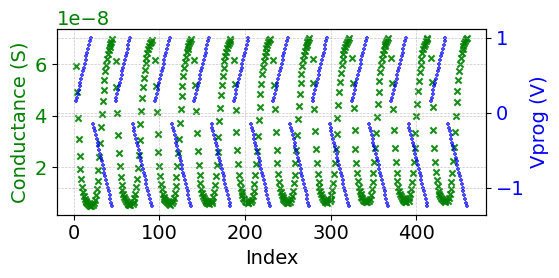

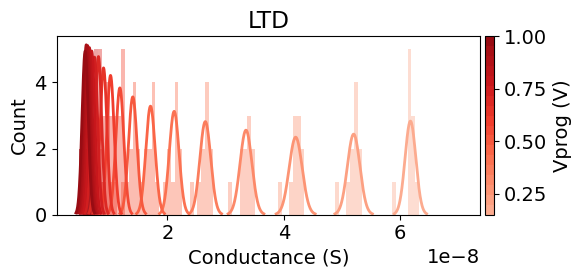

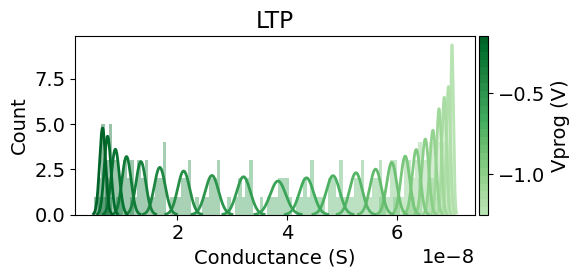

In [45]:

statistics_array = []
# --- inputs ---
round_by = 0.05
vwrite_threshold_pos = 0.1
vwrite_threshold_neg = 0.1

# Ensure ndarray
Vw = np.asarray(V_write, dtype=float)
R  = np.asarray(R_array,  dtype=float)
G = np.asarray(G_array,  dtype=float)
Vw_arr = np.asarray(V_write_array, dtype=float)  # if you need it in the scatter

# support rounding either as "decimal places" (integer round_by) or as a "step" (non-integer, e.g. 1.5 or 0.05)

step = float(round_by)
if step <= 0:
    raise ValueError("round_by used as step must be > 0")
Vw_round = np.round(Vw / step) * step
# remove tiny floating-point noise: choose decimals sufficient for the step
decimals = max(0, int(np.ceil(-np.log10(step))) + 6) if step < 1 else 6
Vw_round = np.round(Vw_round, decimals)
print(np.unique(Vw_round))

# --- select indices in one go ---
# sign of first differences: +1 increase, -1 decrease, 0 same
dV = np.sign(np.diff(Vw, prepend=Vw[0]))

sel = ((Vw_round >  vwrite_threshold_pos) & (dV > 0)) | \
      ((Vw_round < -vwrite_threshold_neg) & (dV < 0))
selected_idx = np.flatnonzero(sel)

# --- quick scatter of selected indices (dual y-axes) ---
# --- scatter of selected indices (dual y-axes) ---
fig, ax = plt.subplots(figsize=(6, 3))


# Right y-axis → Vprog (blue)
ax2 = ax.twinx()
ax2.scatter(selected_idx, Vw_arr[selected_idx], s=5, color='blue', label='Vprog (V)', marker='+', alpha=0.7)
ax2.set_ylabel('Vprog (V)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
# Add grids
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Left y-axis → Conductance (green)
ax.scatter(selected_idx, G[selected_idx], s=20, color='green', label='G (S)', marker='x', alpha=0.9)
ax.set_ylabel('Conductance (S)', color='green')
ax.tick_params(axis='y', labelcolor='green')
#Set y axis in log scale
# ax.set_yscale('log')

ax.set_xlabel('Index')
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)




fig.tight_layout()
#save the figure as svg and name it by number of rounded digits
fig.savefig(f'plots/scatter_selected_indices_roundby{round_by}.svg')


# --- group G by rounded V only for selected points ---
G_by_V = defaultdict(list)
for v, g in zip(Vw_round[selected_idx], G[selected_idx]):
    G_by_V[v].append(g)
# convert lists to arrays
G_by_V = {k: np.asarray(vs) for k, vs in G_by_V.items()}

# common bins across all groups
all_G = np.concatenate([vs for vs in G_by_V.values() if len(vs) > 0]) if G_by_V else np.array([])
if all_G.size == 0:
    raise ValueError("No data after selection; check thresholds.")
bins = np.histogram_bin_edges(all_G, bins=100)

def plot_hist_panel(sign='pos', title=''):
    """sign: 'pos' to plot V > +thr, 'neg' for V < -thr"""
    if sign == 'pos':
        keys = sorted([k for k in G_by_V if k >  vwrite_threshold_pos])
        cmap_base = plt.get_cmap('Reds')
    else:
        keys = sorted([k for k in G_by_V if k < -vwrite_threshold_neg])
        cmap_base = plt.get_cmap('Greens')

    if len(keys) == 0:
        print(f"No groups to plot for sign={sign}")
        return
    

    cmap = ListedColormap(cmap_base(np.linspace(0.3, 0.9, len(keys))))

    plt.figure(figsize=(6, 3))
    ax = plt.gca()
    for i, v in enumerate(keys):
        data = G_by_V[v]
        if data.size == 0:
            continue

        # histogram (counts, not density)
        counts, _ = np.histogram(data, bins=bins)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        ax.bar(bin_centers, counts, width=np.diff(bins), alpha=0.4,
               color=cmap(i % cmap.N), align='center', label=f'Vprog={v} V')

        # gaussian fit scaled to counts
        mu, std = norm.fit(data)
        statistics_array.append([v, mu, std, std/mu*100])  # append RSD in percentage
        print(f"Vprog={v} V: mu={mu:.2f}, std={std:.2f}, rsd={std/mu:.2%}")
        x = np.linspace(mu - 3*std, mu + 3*std, 200)
        p = norm.pdf(x, mu, std)
        scale = data.size * np.diff(bins)[0]
        ax.plot(x, p * scale, color=cmap(i % cmap.N), linewidth=2)

    # ax.set_xscale('log')
    ax.set_xlabel('Conductance (S)')
    ax.set_ylabel('Count')
    ax.set_title(title)

    # colorbar reflecting V values in this panel
    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=min(keys), vmax=max(keys)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('Vprog (V)')

    plt.tight_layout()
    # save figure as svg with sign in filename
    plt.savefig(f'plots/hist_G_by_V_{sign}_roundby{round_by}.svg')

# --- plots ---
plot_hist_panel(sign='pos', title='LTD')
plot_hist_panel(sign='neg', title='LTP')
print("Statistics array (Vprog, G_mean, G_std):")
#Save statistics array as csv file with same name as data_path but with _stats.csv
stats_filename = os.path.splitext(os.path.basename(data_path))[0] + f'_stats_roundby{round_by}.csv'
np.savetxt(os.path.join('plots', stats_filename), statistics_array, delimiter=',',
           header='Vprog,G_mean,G_std,GSD_percent', comments='')
# print(statistics_array.shape)


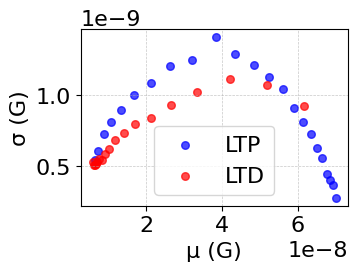

In [47]:
statistics_array = np.array(statistics_array)

statistics_array = np.array(statistics_array)
Vprog = statistics_array[:, 0]
G_mean = statistics_array[:, 1]
G_std = statistics_array[:, 2]
G_RSD = statistics_array[:, 3]  # in percentage

Vprog_ltp = Vprog[Vprog < -vwrite_threshold_neg]
G_mean_ltp = G_mean[Vprog < -vwrite_threshold_neg]
G_std_ltp = G_std[Vprog < -vwrite_threshold_neg]
G_RSD_ltp = G_RSD[Vprog < -vwrite_threshold_neg]

Vprog_ltd = Vprog[Vprog > vwrite_threshold_pos]
G_mean_ltd = G_mean[Vprog > vwrite_threshold_pos]
G_std_ltd = G_std[Vprog > vwrite_threshold_pos]
G_RSD_ltd = G_RSD[Vprog > vwrite_threshold_pos]

plt.figure(figsize=(4,3))
#Set font size to 14
plt.rcParams.update({'font.size': 16})
plt.scatter(G_mean_ltp, G_std_ltp, color='blue', s=30, alpha=0.7, label='LTP')
plt.scatter(G_mean_ltd, G_std_ltd, color='red', s=30, alpha=0.7, label='LTD')
plt.legend()
plt.xlabel('μ (G)')
plt.ylabel('σ (G)')
#Set x limit from 0 to 1
# plt.xlim(0, 1.1)
#Add grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('plots/Conductance_Std_vs_Mean.svg')
# plt.title('Weight Standard Deviation (%) vs Vprog')

Overall mean G: 0.00 S
Vprog=0.1 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=1.80%
Vprog=0.15 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=2.85%
Vprog=0.2 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=3.31%
Vprog=0.25 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=3.45%
Vprog=0.3 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=3.16%
Vprog=0.35 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=2.87%
Vprog=0.4 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=2.58%
Vprog=0.45 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=2.46%
Vprog=0.5 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=2.27%
Vprog=0.55 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=2.11%
Vprog=0.6 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=1.92%
Vprog=0.65 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=1.82%
Vprog=0.7 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=1.69%
Vprog=0.75 V: G_mean=0.00 S, G_std=0.00 S, RSD% (overall mean)=1.69%
Vprog=0.8 V: G_mea

Text(0.5, 1.0, 'RSD vs Mean Conductance')

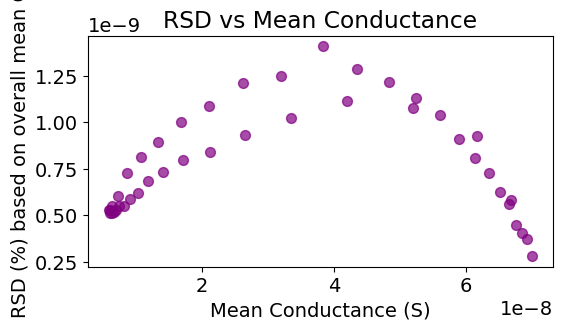

In [39]:
#From the statistics array, calculate the mean of all G_mean and then recalculate the RSD percent for each Vprog based on this overall mean

statistics_array = np.array(statistics_array)
overall_mean_G = np.mean(statistics_array[:, 1])
print(f"Overall mean G: {overall_mean_G:.2f} S")

G_mean_values = statistics_array[:, 1]
G_RSD_values = np.zeros_like(G_mean_values)

for i, row in enumerate(statistics_array):
    vprog = row[0]
    g_mean = row[1]
    g_std = row[2]
    rsd_percent = (g_std / overall_mean_G) * 100
    G_RSD_values[i] = g_std
    print(f"Vprog={vprog} V: G_mean={g_mean:.2f} S, G_std={g_std:.2f} S, RSD% (overall mean)={rsd_percent:.2f}%")
#Plot G_RSD vs G_mean
plt.figure(figsize=(6,3))
plt.scatter(G_mean_values, G_RSD_values, color='purple', s=50, marker='o', alpha=0.7)
plt.xlabel('Mean Conductance (S)')
plt.ylabel('RSD (%) based on overall mean G')
plt.title('RSD vs Mean Conductance')
    
    

LTD (+V): mean z-sep = 1.89, median z-sep = 1.35; mean overlap = 0.328
LTP (−V): mean z-sep = 2.30, median z-sep = 2.29; mean overlap = 0.167


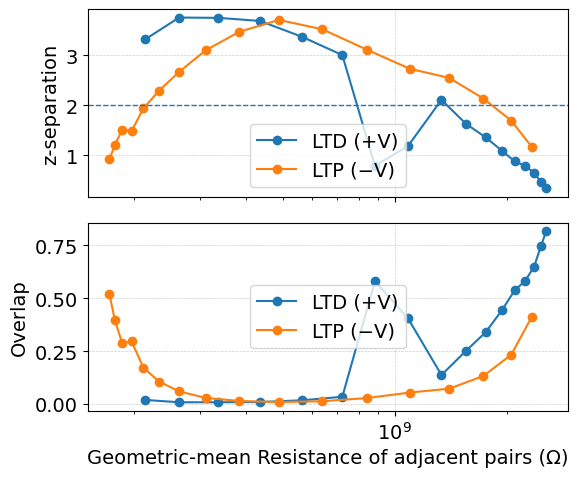

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# =========================
# Inputs 
# =========================
# V_write: 1D array of applied programming voltage per sample
# R_array: 1D array of resistance per sample (same length/order as V_write)
# V_write_array: optional; if not provided, the same as V_write is used in the scatter elsewhere.
V_write = np.asarray(V_write, dtype=float)
R_array  = np.asarray(R_array,  dtype=float)
round_by = 0.05
vwrite_threshold_pos = 0.1
vwrite_threshold_neg = 0.1

# =========================
# Helper: bin by rounded V and keep only monotone segments beyond thresholds
# =========================
step = float(round_by)
if step <= 0:
    raise ValueError("round_by must be > 0")

Vw_round = np.round(np.round(V_write/step)*step, decimals=max(0, int(np.ceil(-np.log10(step)))+6) if step<1 else 6)

# Direction of change (+1 increasing, -1 decreasing)
dV = np.sign(np.diff(V_write, prepend=V_write[0]))

sel = ((Vw_round >  vwrite_threshold_pos) & (dV > 0)) | \
      ((Vw_round < -vwrite_threshold_neg) & (dV < 0))
idx = np.flatnonzero(sel)

# Group R by rounded V for selected points
from collections import defaultdict
R_by_V = defaultdict(list)
for v, r in zip(Vw_round[idx], R_array[idx]):
    R_by_V[float(v)].append(float(r))
R_by_V = {k: np.asarray(vs) for k, vs in R_by_V.items() if len(vs) > 0}

# Partition keys
keys_pos = sorted([k for k in R_by_V if k >  vwrite_threshold_pos])
keys_neg = sorted([k for k in R_by_V if k < -vwrite_threshold_neg])

# =========================
# Stats in log-space (log10 R): mean, std, n, and mean-R for reference
# =========================
def fit_stats_logR(R_by_V, keys):
    out = []
    for v in keys:
        x = np.log10(R_by_V[v])
        if x.size < 2:  # need at least 2 for std
            continue
        mu = x.mean()
        sd = x.std(ddof=1)
        n  = x.size
        out.append([v, mu, sd, n, 10**mu])  # include mean R
    return np.array(out, float)  # columns: V, mu_logR, sd_logR, n, meanR

stats_pos = fit_stats_logR(R_by_V, keys_pos)
stats_neg = fit_stats_logR(R_by_V, keys_neg)

# Early exit if not enough groups
if (stats_pos.shape[0] < 2) and (stats_neg.shape[0] < 2):
    raise ValueError("Not enough V groups on either side to compute adjacent metrics.")

# =========================
# Adjacent-pair metrics in log-space
# =========================
def adjacent_metrics(stats):
    # stats: [V, mu, sd, n, meanR]
    mu = stats[:,1]; sd = stats[:,2]
    # z-separation: |Δμ| / sqrt(σ_i^2 + σ_{i+1}^2)
    z = np.abs(np.diff(mu)) / np.sqrt(sd[:-1]**2 + sd[1:]**2)
    # overlap coefficient (approx) between two Gaussians in log-space
    d = np.abs(np.diff(mu)) / np.sqrt(2*(sd[:-1]**2 + sd[1:]**2))
    ovl = 2*norm.cdf(-d)  # 0 = no overlap, 1 = full overlap
    # X-axis = geometric-mean resistance of adjacent groups
    x_pairs = 10**(0.5*(mu[:-1] + mu[1:]))
    return x_pairs, z, ovl

x_pos, z_pos, ovl_pos = (np.array([]), np.array([]), np.array([]))
x_neg, z_neg, ovl_neg = (np.array([]), np.array([]), np.array([]))

if stats_pos.shape[0] >= 2:
    x_pos, z_pos, ovl_pos = adjacent_metrics(stats_pos)
if stats_neg.shape[0] >= 2:
    x_neg, z_neg, ovl_neg = adjacent_metrics(stats_neg)

# =========================
# Plot: two panels, same X (mean R of adjacent pairs, log scale)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# 1) Adjacent z-separation (higher is better)
ax = axes[0]
if x_pos.size:
    ax.plot(x_pos, z_pos, marker='o', label='LTD (+V)')
if x_neg.size:
    ax.plot(x_neg, z_neg, marker='o', label='LTP (−V)')
ax.axhline(2, linestyle='--', linewidth=1)  # rough "good separation" guide
ax.set_ylabel('z-separation')
ax.legend(loc='best')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# 2) Adjacent overlap (lower is better)
ax = axes[1]
if x_pos.size:
    ax.plot(x_pos, ovl_pos, marker='o', label='LTD (+V)')
if x_neg.size:
    ax.plot(x_neg, ovl_neg, marker='o', label='LTP (−V)')
ax.set_ylabel('Overlap')
ax.set_xlabel('Geometric-mean Resistance of adjacent pairs (Ω)')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax.legend(loc='best')

for ax in axes:
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig('plots/separation_metrics_vs_R.svg', bbox_inches='tight')
# plt.show()

# =========================
# Optional: quick numeric summaries
# =========================
def summarize(name, x, z, ovl):
    if x.size == 0:
        print(f"{name}: not enough groups.")
        return
    print(f"{name}: mean z-sep = {np.nanmean(z):.2f}, "
          f"median z-sep = {np.nanmedian(z):.2f}; "
          f"mean overlap = {np.nanmean(ovl):.3f}")

summarize("LTD (+V)", x_pos, z_pos, ovl_pos)
summarize("LTP (−V)", x_neg, z_neg, ovl_neg)
